# 01 · Simulated data and exploratory analysis

**OneMore** is a small web app where friends challenge each other to do 100 push-ups a day:
quick buttons (+10, +20, +25, +30) log a *set*, anything beyond the daily goal is not counted,
and every set sends a push notification to the user's friends.

The real usage data belongs to a handful of friends: too small and too private to publish. So
this project starts from a **simulator with a known ground truth**. It reproduces the app's
mechanics and plants behavioural effects of a chosen size; every later notebook then has to
*recover* those effects from the observable tables alone. That turns the analysis from
"here is a number" into "here is a method, and here is proof it works".

| Planted effect | Parameter | Checked in |
|---|---|---|
| Users differ in motivation | `motivation_sd` | 01, 02 |
| Streaks build habits | `habit_strength` | 02 |
| Novelty wears off | `novelty_decay` | 01 |
| Weekends are harder | `weekend_effect` | 01 |
| Friends sometimes train together (a confounder) | `together_prob`, `together_boost` | 04 |
| **A friend's notification raises your set rate** | `notification_effect` | 04 |

The observable tables have exactly the schema of the app export
(`python manage.py export_analysis_data`), so every notebook also runs on real data.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from onemore_analysis import SimConfig, simulate
from onemore_analysis.plotting import use_style, subtitle, date_axis, SERIES, REFERENCE, MUTED, INK_SECONDARY, GRID

use_style()
pd.set_option("display.precision", 3)
pd.set_option("display.width", 120)

## Ground truth
The configuration below *is* the truth the analyses try to recover.

In [2]:
cfg = SimConfig()
sim = simulate(cfg)
truth = pd.Series({k: v for k, v in sim.meta["config"].items() if k not in ("group_sizes", "start")}, name="value")
truth.to_frame()

,value
n_days,120.00
goal,100.00
slot_minutes,10.00
base_logit,1.00
motivation_sd,1.00
habit_strength,0.60
novelty_decay,1.20
weekend_effect,-0.60
group_day_sd,0.40
mean_sets_per_day,5.50


In [3]:
print(f"{cfg.n_users} users in {len(cfg.group_sizes)} friend groups, {cfg.n_days} days")
for name in ("users", "edges", "entries", "daily", "notifications"):
    print(f"{name:14s} {len(getattr(sim, name)):>8,} rows")
sim.entries.head()

60 users in 9 friend groups, 120 days
users                60 rows
edges               372 rows
entries          19,215 rows
daily             7,200 rows
notifications   122,378 rows


,user_id,day,ts,reps
0,11,2026-01-05,2026-01-05 06:33:40.764203,20
1,37,2026-01-05,2026-01-05 06:35:41.813967,10
2,49,2026-01-05,2026-01-05 06:32:53.568821,30
3,52,2026-01-05,2026-01-05 06:37:26.228354,30
4,54,2026-01-05,2026-01-05 06:37:52.270747,30


## How many people hit 100 each day?

The daily completion rate starts around one in two and slowly declines: the planted
`novelty_decay`. Weekly dips come from weekends.

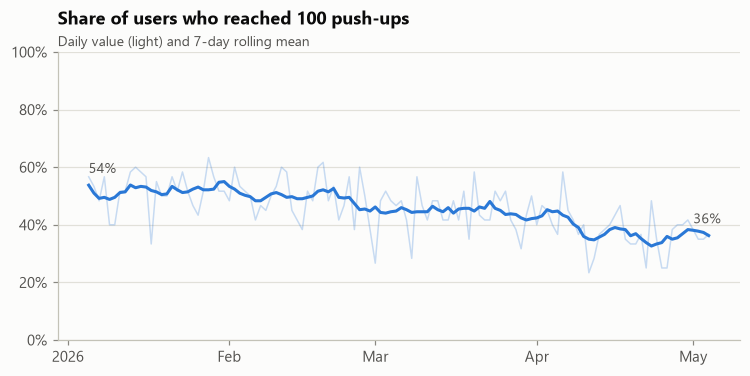

week,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
completion rate,0.495,0.533,0.521,0.524,0.498,0.495,0.521,0.452,0.448,0.464,0.457,0.436,0.431,0.39,0.39,0.326,0.383,0.367


In [4]:
daily_rate = sim.daily.groupby("day")["completed"].mean()
rolling = daily_rate.rolling(7, center=True, min_periods=4).mean()

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(daily_rate.index, daily_rate.values, color=SERIES[0], alpha=0.25, linewidth=1)
ax.plot(rolling.index, rolling.values, color=SERIES[0])
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
date_axis(ax)
ax.set_title("Share of users who reached 100 push-ups", pad=18)
subtitle(ax, "Daily value (light) and 7-day rolling mean")
ax.annotate(f"{rolling.dropna().iloc[0]:.0%}", (rolling.dropna().index[0], rolling.dropna().iloc[0]),
            textcoords="offset points", xytext=(0, 8), color=INK_SECONDARY, fontsize=9)
ax.annotate(f"{rolling.dropna().iloc[-1]:.0%}", (rolling.dropna().index[-1], rolling.dropna().iloc[-1]),
            textcoords="offset points", xytext=(-10, 8), color=INK_SECONDARY, fontsize=9)
plt.show()

weekly = sim.daily.assign(week=lambda d: d["day"].dt.isocalendar().week).groupby("week")["completed"].mean()
weekly.rename("completion rate").to_frame().T

## When do people train?
Three peaks (morning, lunch, evening), mixed per user.

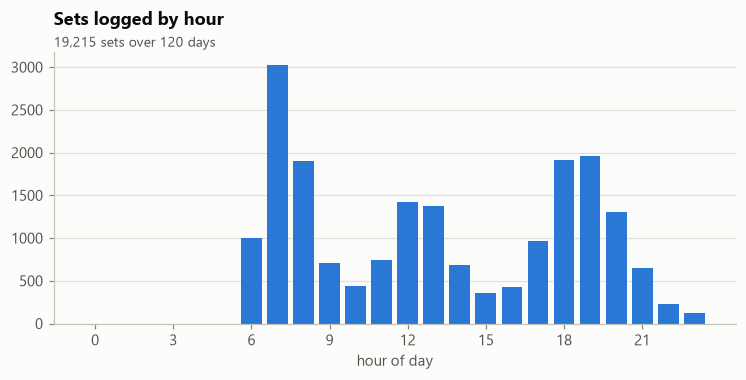

ts,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
sets,998,3020,1902,703,439,742,1425,1373,683,361,424,970,1913,1957,1308,646,229,122


In [5]:
by_hour = sim.entries["ts"].dt.hour.value_counts().reindex(range(24), fill_value=0)

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(by_hour.index, by_hour.values, width=0.8, color=SERIES[0])
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("hour of day")
ax.set_title("Sets logged by hour", pad=18)
subtitle(ax, f"{len(sim.entries):,} sets over {cfg.n_days} days")
plt.show()
by_hour[by_hour > 0].rename("sets").to_frame().T

## Weekends are harder
The planted `weekend_effect` lowers engagement on Saturday and Sunday.

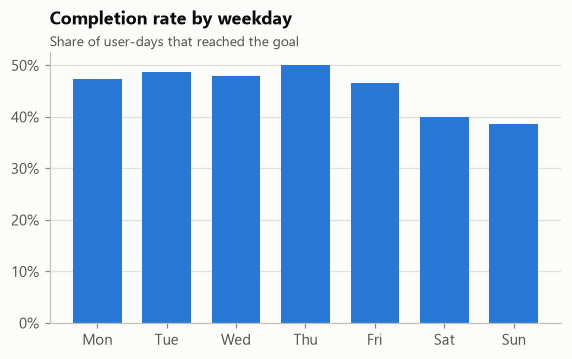

,Mon,Tue,Wed,Thu,Fri,Sat,Sun
completion rate,0.473,0.486,0.479,0.501,0.467,0.4,0.385


In [6]:
names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_wd = sim.daily.assign(wd=sim.daily["day"].dt.dayofweek).groupby("wd")["completed"].mean()

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(names, by_wd.values, width=0.7, color=SERIES[0])
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set_title("Completion rate by weekday", pad=18)
subtitle(ax, "Share of user-days that reached the goal")
plt.show()
by_wd.set_axis(names).rename("completion rate").to_frame().T

## Users are very different

The per-user completion rate is spread from almost never to almost always. Because this is
a simulation we can check what drives it: the hidden `motivation` of each user.

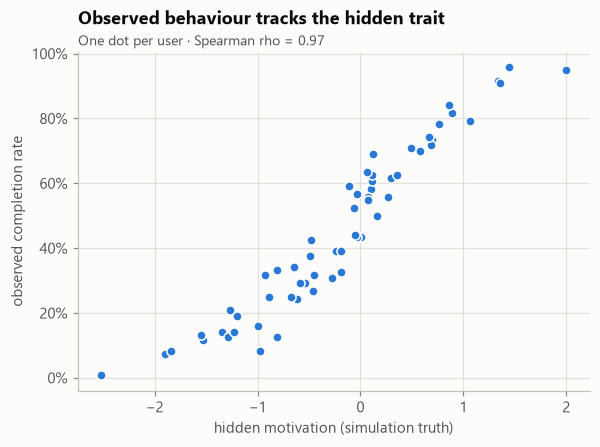

,count,mean,std,min,25%,50%,75%,max
completion_rate,60.0,0.456,0.256,0.008,0.250,0.433,0.627,0.958
motivation,60.0,-0.209,0.889,-2.517,-0.808,-0.089,0.278,2.000


In [7]:
per_user = (sim.daily.groupby("user_id")["completed"].mean().rename("completion_rate")
            .to_frame().join(sim.truth_users.set_index("user_id")["motivation"]))
rho = per_user.corr(method="spearman").iloc[0, 1]

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(per_user["motivation"], per_user["completion_rate"], s=36, color=SERIES[0],
           edgecolor="white", linewidth=1)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set_xlabel("hidden motivation (simulation truth)")
ax.set_ylabel("observed completion rate")
ax.grid(axis="x")
ax.set_title("Observed behaviour tracks the hidden trait", pad=18)
subtitle(ax, f"One dot per user · Spearman rho = {rho:.2f}")
plt.show()
per_user.describe().T

## Set sizes
Users mostly tap the four buttons; the last set of a day is often capped at the goal.

In [8]:
sizes = sim.entries["reps"].value_counts(normalize=True).sort_index()
sizes.rename("share of sets").to_frame().T

reps,5,10,15,20,25,30
share of sets,0.029,0.278,0.027,0.213,0.231,0.222


## Takeaways

* The simulated data looks like a plausible habit app: ~50% daily completion at first,
  slowly decaying, strong weekly rhythm and very heterogeneous users.
* Heterogeneity matters for everything that follows: comparisons that pool users can be
  driven by *who* the users are rather than by what happened to them.

Next: [02 · How long do streaks last?](02_streak_survival.ipynb)